In [202]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
#from sklearn.model_selection import train_test_split

In [203]:

path=kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
file_path=os.path.join(path,"Mall_Customers.csv")
df=pd.read_csv(file_path)

print("جاري تنزيل بيانات المتجر")


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
جاري تنزيل بيانات المتجر


In [204]:
#df.head()
df.sample(10)#عشر بيانات عشوائية

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
175,176,Female,30,88,86
152,153,Female,44,78,20
23,24,Male,31,25,73
150,151,Male,43,78,17
57,58,Male,69,44,46
36,37,Female,42,34,17
22,23,Female,46,25,5
99,100,Male,20,61,49
19,20,Female,35,23,98
46,47,Female,50,40,55


In [205]:
df.shape

(200, 5)

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [207]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [208]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [209]:
df.duplicated().sum()

np.int64(0)

##Transform Data


In [210]:
la=LabelEncoder()
df['Gender']=la.fit_transform(df['Gender'])

In [211]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


##Creat Module

In [212]:
scaler=StandardScaler()
numirac_colomns=df[['Age','Annual Income (k$)','Spending Score (1-100)']]
df_scaled_numirac=scaler.fit_transform(numirac_colomns)
df_scaled_numirac_df = pd.DataFrame(df_scaled_numirac, columns=['Age','Annual Income (k$)','Spending Score (1-100)'])
df_scaled_numirac_df['Gender']=df['Gender']
df_scaled_numirac_df['CustomerID']=df['CustomerID']
display(df_scaled_numirac_df.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender,CustomerID
0,-1.424569,-1.738999,-0.434801,1,1
1,-1.281035,-1.738999,1.195704,1,2
2,-1.352802,-1.700830,-1.715913,0,3
3,-1.137502,-1.700830,1.040418,0,4
4,-0.563369,-1.662660,-0.395980,0,5


In [213]:
clusters=[]
j=[]

In [214]:
for i in range(1,12):
   module=KMeans(n_clusters=i)
   module.fit(df_scaled_numirac_df)
   clusters.append(i)
   j.append(module.inertia_)

In [215]:
pd.DataFrame(clusters,j)

,0
667299.280000,1
167219.220070,2
74584.058305,3
42240.468699,4
27205.119862,5
19064.304367,6
14102.401474,7
10902.221156,8
8740.626245,9
7193.919727,10


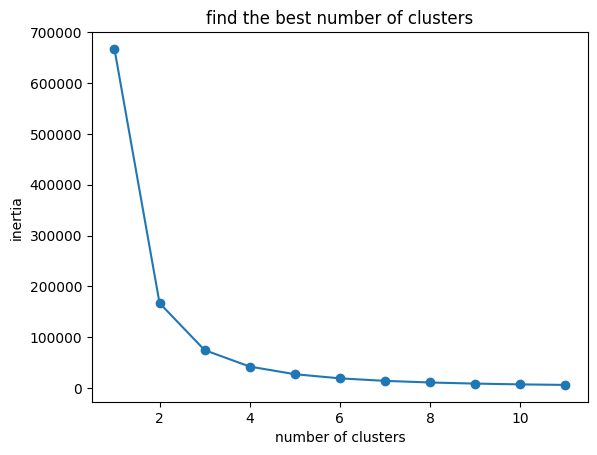

In [216]:
plt.plot(clusters,j,marker='o')
plt.title('find the best number of clusters')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.show()

In [217]:
module=KMeans(n_clusters=4)
module.fit(df)
pre=module.predict(df)


In [218]:
df['K_Mean']=pre

In [219]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Mean
0,1,1,19,15,39,0
1,2,1,21,15,81,3
2,3,0,20,16,6,0
3,4,0,23,16,77,3
4,5,0,31,17,40,0
...,...,...,...,...,...,...
195,196,0,35,120,79,2
196,197,0,45,126,28,2
197,198,1,32,126,74,2
198,199,1,32,137,18,2


In [220]:

df1=df[df['K_Mean']==1]
df2=df[df['K_Mean']==2]
df3=df[df['K_Mean']==3]
df0=df[df['K_Mean']==0]

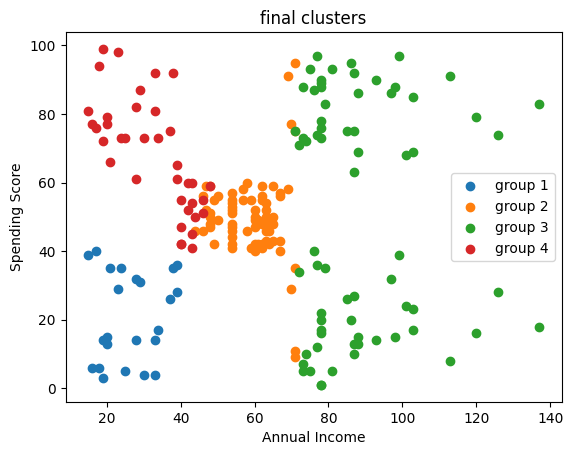

In [221]:
plt.scatter(df0['Annual Income (k$)'],df0['Spending Score (1-100)'],label='group 1')
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'],label='group 2')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'],label='group 3')
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'],label='group 4')
plt.title('final clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [222]:
module=KMeans(n_clusters=4)
module.fit(df_scaled_numirac_df)
pre1=module.predict(df_scaled_numirac_df)


In [223]:
df_scaled_numirac_df['K_Mean']=pre1

In [224]:
df1=df_scaled_numirac_df[df_scaled_numirac_df['K_Mean']==1]
df2=df_scaled_numirac_df[df_scaled_numirac_df['K_Mean']==2]
df3=df_scaled_numirac_df[df_scaled_numirac_df['K_Mean']==3]
df0=df_scaled_numirac_df[df_scaled_numirac_df['K_Mean']==0]

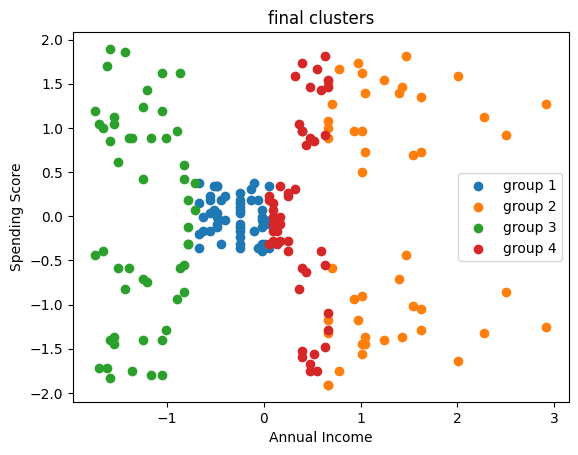

In [225]:
plt.scatter(df0['Annual Income (k$)'],df0['Spending Score (1-100)'],label='group 1')
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'],label='group 2')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'],label='group 3')
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'],label='group 4')
plt.title('final clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

##Data Analysis


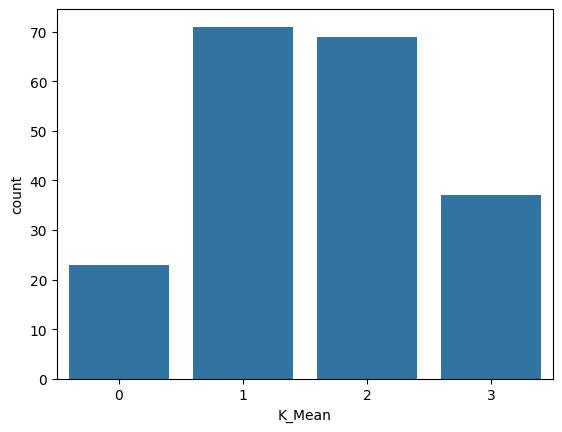

In [226]:
sns.countplot(x=df['K_Mean'])
plt.show()

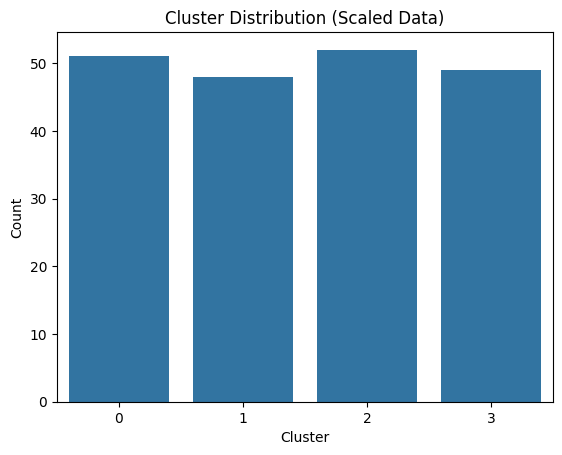

In [227]:
#plt.figure(figsize=(10, 10))
sns.countplot(x=df_scaled_numirac_df['K_Mean'])
plt.title('Cluster Distribution (Scaled Data)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [228]:
print(df['K_Mean'].value_counts())

K_Mean
1    71
2    69
3    37
0    23
Name: count, dtype: int64


In [229]:
print(df_scaled_numirac_df['K_Mean'].value_counts())

K_Mean
2    52
0    51
3    49
1    48
Name: count, dtype: int64


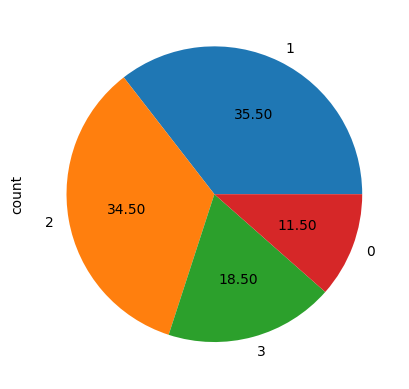

In [230]:
df['K_Mean'].value_counts().plot.pie(autopct='%0.2f')

plt.show()

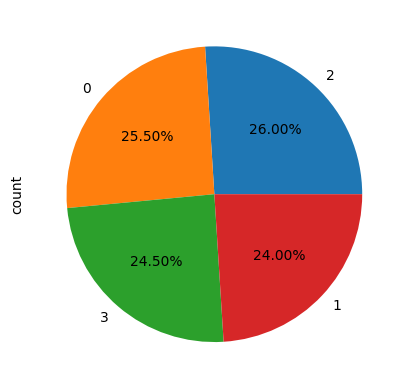

In [231]:
df_scaled_numirac_df['K_Mean'].value_counts().plot.pie(autopct='%0.2f%%')

plt.show()

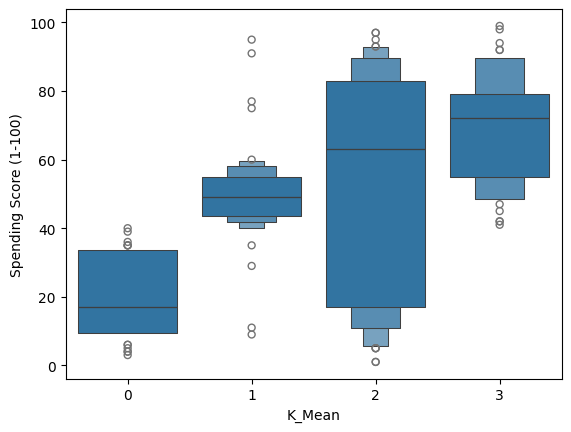

In [232]:
sns.boxenplot(x='K_Mean',y='Spending Score (1-100)',data=df)
plt.show()

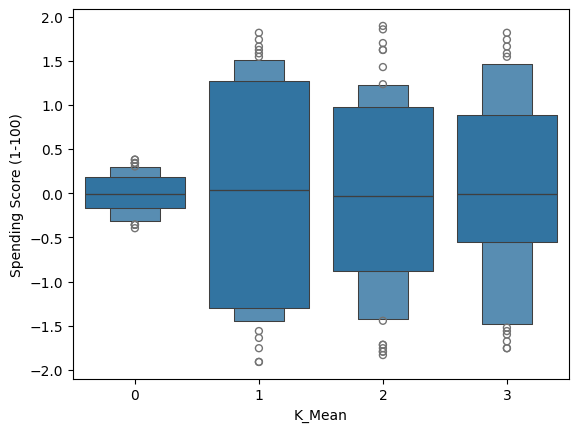

In [233]:
sns.boxenplot(x='K_Mean',y='Spending Score (1-100)',data=df_scaled_numirac_df)
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

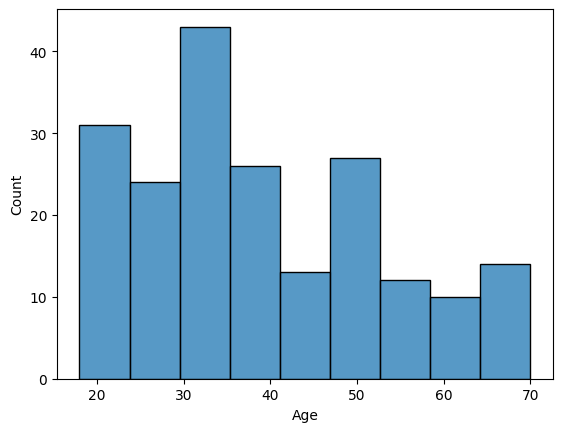

In [234]:
sns.histplot(x='Age', data=df)

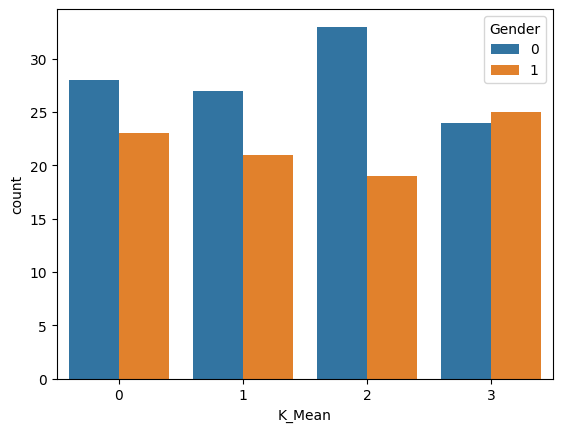

In [235]:
sns.countplot(x='K_Mean', hue='Gender',data=df_scaled_numirac_df)
plt.show()

<Axes: xlabel='Gender', ylabel='count'>

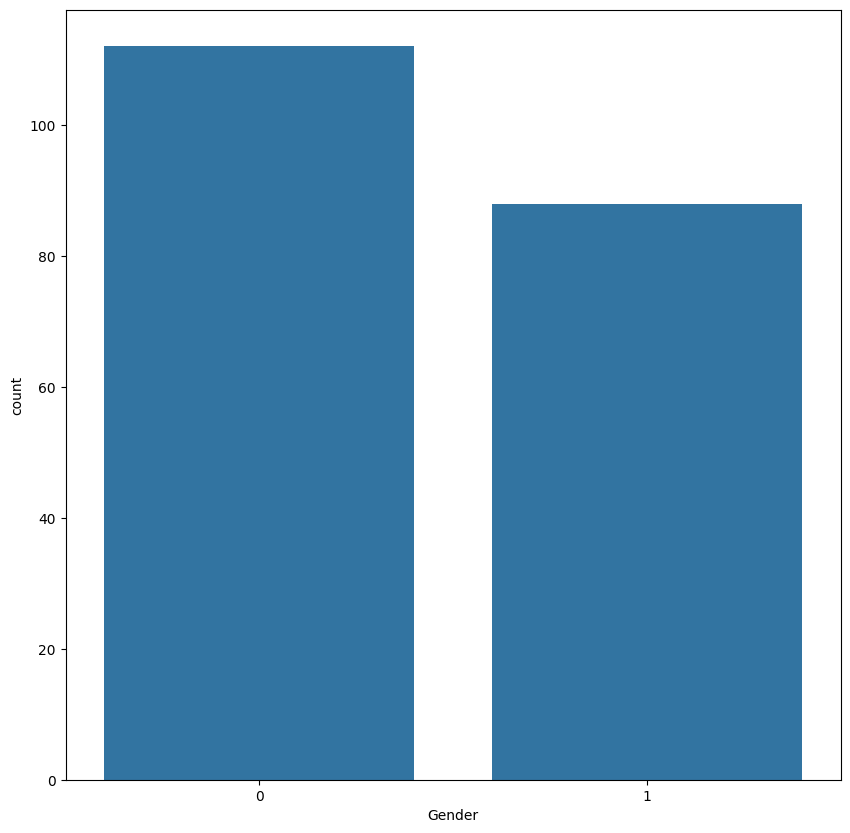

In [238]:
plt.figure(figsize=(10, 10))
sns.countplot(x=df_scaled_numirac_df['Gender'])